<a href="https://colab.research.google.com/github/RekhaThota22/Boston_DecisionTreeRegression/blob/main/BigMart_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1:09 **PM**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import datetime as dt

In [4]:
#1:15
df = pd.read_csv('/content/BigMartSales.csv')

In [5]:
df.shape

(8523, 12)

In [6]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [7]:
df.columns = (
    df.columns.str.strip().str.lower().str.replace(' ','_')
)

In [8]:
df.columns

Index(['item_identifier', 'item_weight', 'item_fat_content', 'item_visibility',
       'item_type', 'item_mrp', 'outlet_identifier',
       'outlet_establishment_year', 'outlet_size', 'outlet_location_type',
       'outlet_type', 'item_outlet_sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_identifier            8523 non-null   object 
 1   item_weight                7060 non-null   float64
 2   item_fat_content           8523 non-null   object 
 3   item_visibility            8523 non-null   float64
 4   item_type                  8523 non-null   object 
 5   item_mrp                   8523 non-null   float64
 6   outlet_identifier          8523 non-null   object 
 7   outlet_establishment_year  8523 non-null   int64  
 8   outlet_size                6113 non-null   object 
 9   outlet_location_type       8523 non-null   object 
 10  outlet_type                8523 non-null   object 
 11  item_outlet_sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [10]:
df.describe()

,item_weight,item_visibility,item_mrp,outlet_establishment_year,item_outlet_sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [11]:
df.isnull().sum()

,0
item_identifier,0
item_weight,1463
item_fat_content,0
item_visibility,0
item_type,0
item_mrp,0
outlet_identifier,0
outlet_establishment_year,0
outlet_size,2410
outlet_location_type,0


In [12]:
# item_values,outlet_size but not small to drop so need to fill
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])
  else :
    df[col] = df[col].fillna(df[col].median())

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Identifying the num cols
num_cols = df.select_dtypes(include = np.number).columns

In [15]:
# cat cols
cat_cols = df.select_dtypes(include = 'object').columns

<Axes: xlabel='item_mrp', ylabel='Count'>

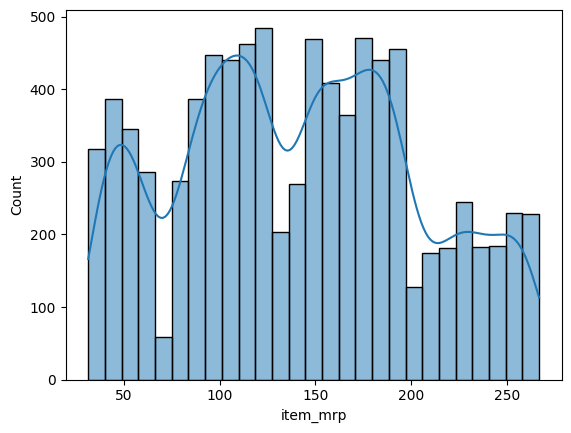

In [16]:
sns.histplot(df['item_mrp'],kde = True)

<Axes: ylabel='item_outlet_sales'>

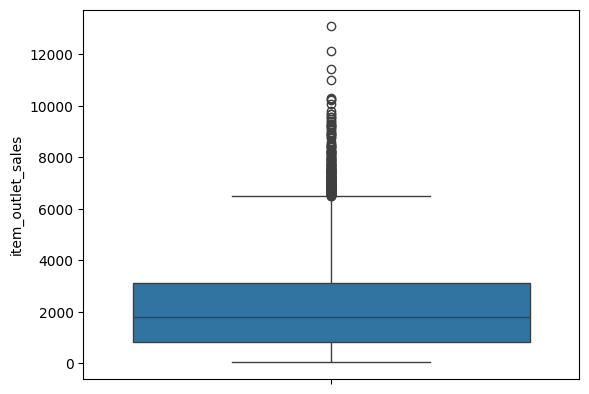

In [17]:
sns.boxplot(df['item_outlet_sales'])

<Axes: >

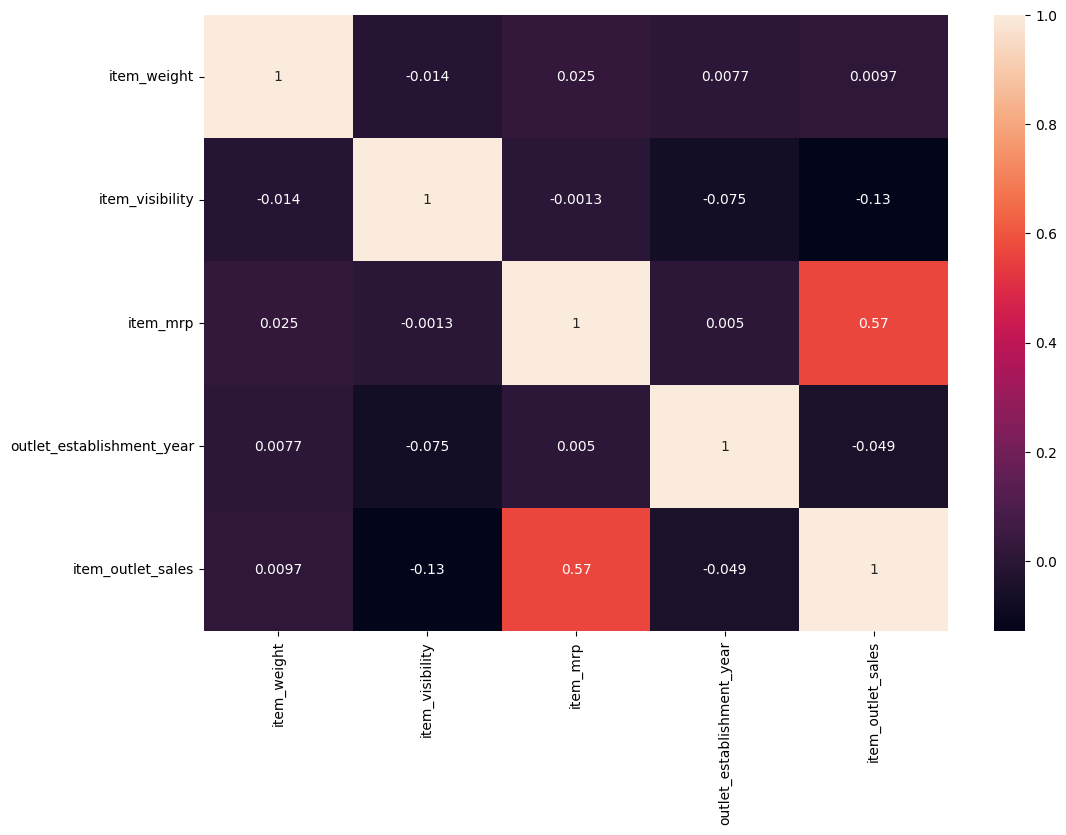

In [18]:
from matplotlib import colormaps
# Correlation
corr = df.corr(numeric_only = True)

plt.figure(figsize=(12,8))

sns.heatmap(corr,annot = True )

In [19]:
# defining the outlet age

df['outlet_age'] = dt.datetime.now().year - df['outlet_establishment_year']

In [20]:
# Encoding
df = pd.get_dummies(df,drop_first = True)

In [21]:
# Feature & target split
X = df.drop('item_outlet_sales',axis = 1)
y = df['item_outlet_sales']

In [22]:
# train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [23]:
# 1:48
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

# BASELINE LINEAR REGRESSION

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)


In [25]:
# Evaluating the performance:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(f'MSE :{mean_squared_error(y_test,y_pred)}')
print(f'MAE :{mean_absolute_error(y_test,y_pred)}')
print(f'R2_score  :{r2_score(y_test,y_pred)}')

MSE :1622406.648825544
MAE :944.2749906454409
R2_score  :0.40308148763202345


# Found
Model isn't working great as R2 is very low and MSE penelizes way too much so switching to RandiomForest

In [26]:
# Random Forest scaling isnt needed

In [27]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 100,random_state = 42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [28]:
print(f'MSE :{mean_squared_error(y_test,y_pred)}')
print(f'MAE :{mean_absolute_error(y_test,y_pred)}')
print(f'R2_score  :{r2_score(y_test,y_pred)}')

MSE :1200476.94129324
MAE :762.4635462498534
R2_score  :0.5583185569120078


In [29]:
#2:09
#3:19
importance = pd.DataFrame({
    'Feature' : X.columns,
     'Importance' : model.feature_importances_
})

importance.sort_values(
    by = 'Importance',
    ascending = False,
    inplace = True
)
print(importance.head(10))


                            Feature  Importance
2                          item_mrp    0.397195
1595  outlet_type_Supermarket Type1    0.095822
1                   item_visibility    0.057202
1586       outlet_identifier_OUT027    0.055228
1597  outlet_type_Supermarket Type3    0.051604
3         outlet_establishment_year    0.030183
0                       item_weight    0.030108
4                        outlet_age    0.019484
1596  outlet_type_Supermarket Type2    0.016295
1584       outlet_identifier_OUT018    0.015332


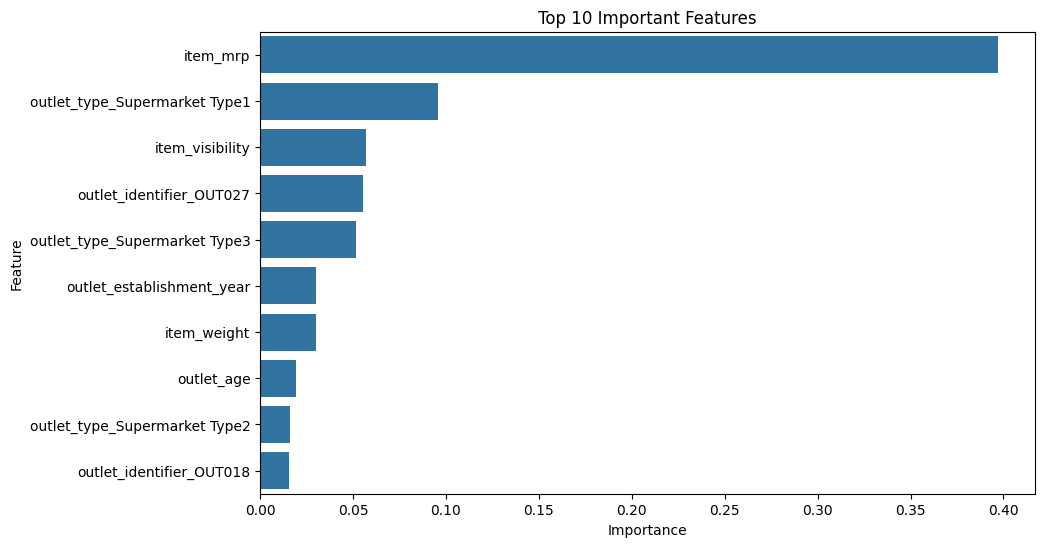

In [30]:
# Visualizing the importances
plt.figure(figsize=(10,6))

sns.barplot(x = 'Importance',
            y = 'Feature',
            data = importance.head(10))
plt.title('Top 10 Important Features')
plt.show()

In [31]:
# Checking the model for overfitting:
train_score = model.score(X_train,y_train)
print(f'train_score : {train_score}')

test_score = model.score(X_test,y_test)
print(f'test_score : {test_score}')

train_score : 0.9363493071392591
test_score : 0.5583185569120078


In [32]:
rf2 = RandomForestRegressor(n_estimators=100,
                            max_depth = 10,
                            min_samples_split = 10,
                            random_state = 42)
rf2.fit(X_train,y_train)
y_pred = rf2.predict(X_test)

In [33]:
train_score2 = rf2.score(X_train,y_train)
test_score2 = rf2.score(X_test,y_test)

print(f'train_score : {train_score2}')
print(f'test_score : {test_score2}')

train_score : 0.6877545581855777
test_score : 0.6088231144310448


# Cross_validation:

In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf2,
    X,
    y,
    scoring= 'r2'
)
print(scores)

print(scores.mean())

[0.60730067 0.57233648 0.56825621 0.6024809  0.60481953]
0.5910387565066897


# HyperParameter Tuning:

In [35]:
  # For LR - coefficients
  # Fore RF - n_estimators,min_samples_split,max_depth
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators' : [50,100],
    'max_depth' : [5,10,15],
    'min_samples_split' : [2,5,10]
  }

grid = GridSearchCV(
      RandomForestRegressor(random_state = 42),
      params,
      cv = 5,
      scoring = 'r2',
      n_jobs = -1
  )
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100]},
             scoring='r2')

In [36]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
0.5939702857313669


# PCA

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [38]:
print(X_train_scaled.shape)
print(X_train_pca.shape)

(6818, 1598)
(6818, 1481)


In [40]:
residuals = y_test -y_pred

<Axes: xlabel='item_outlet_sales', ylabel='Count'>

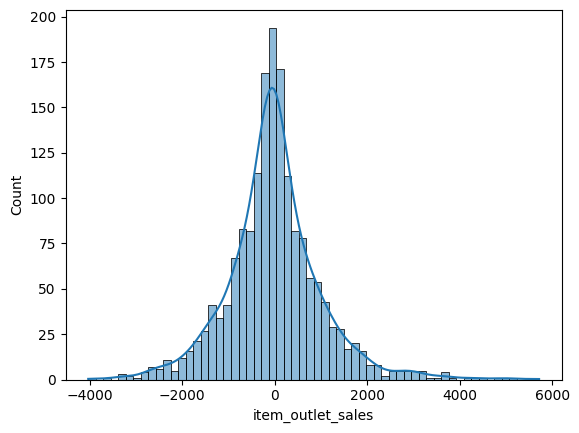

In [41]:
sns.histplot(residuals,kde = True)

#Residual Scatter plot

Text(0.5, 1.0, 'Residual Scatter Plot')

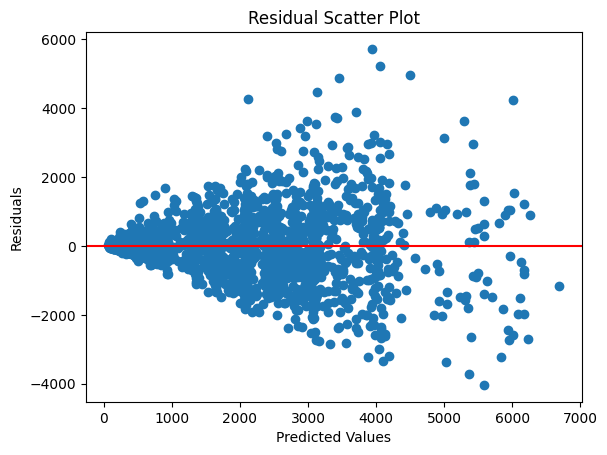

In [46]:
plt.scatter(y_pred,residuals)
plt.axhline(y = 0,color = 'red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Scatter Plot')

Text(0.5, 1.0, 'Residual Scatter Plot')

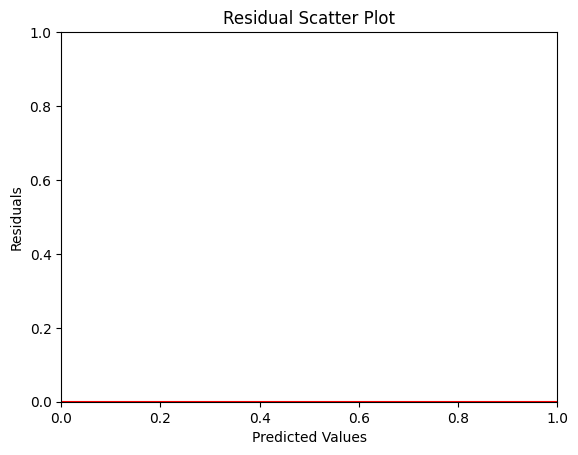